# 因子分析：学生生活・健康・学習習慣データから「隠れた因子」を探す

このNotebookでは、学生の生活習慣・学習状況・メンタル状態に関する量的データを使って、因子分析を行う。

前回の主成分分析（PCA）は、たくさんの変数を少ない軸に要約する方法だった一方、因子分析は、観測された変数の背後にある「共通因子」を探す方法である。

今回のゴールは、以下のような潜在的な因子を見つけることである：

- 健康・生活習慣因子
- 学習習慣因子
- メンタル負荷因子

## 1. ライブラリの読み込み

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

## 2. データの読み込み

`student_lifestyle_survey.csv` を読み込む。  
あわせて、各カラムの意味をまとめた `metadata_description.csv` も確認する。

In [2]:
# リポジトリのルートを基準にする
# Notebookの場所：03_factor_analysis/notebook/03_factor_analysis.ipynb
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "student_lifestyle_survey.csv"
META_PATH = BASE_DIR / "data" / "metadata_description.csv"

df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(META_PATH)

df.head()

,student_id,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score
0,S001,7.2,45,3.1,2.5,92,120,1.8,35,28,30,21.5,62,95,82
1,S002,5.4,10,7.2,1.2,68,340,5.5,74,80,77,27.2,81,60,55
2,S003,6.8,30,4.1,4.5,96,180,2.3,42,35,40,22.1,66,98,91
3,S004,8.1,60,2.0,3.1,88,90,1.2,22,20,24,20.4,58,93,86
4,S005,4.9,5,8.3,0.8,55,410,6.8,88,91,85,29.1,89,42,48


In [3]:
metadata

,column_name,data_type,unit,description,analysis_note
0,student_id,string,-,学生ID,分析対象から除外するID列
1,sleep_hours,float,hours/day,1日あたりの平均睡眠時間,健康因子に関係
2,exercise_minutes,int,minutes/day,1日あたりの平均運動時間,健康因子に関係
3,screen_time_hours,float,hours/day,1日あたりのスクリーンタイム,生活習慣・メンタル負荷に関係
4,study_hours,float,hours/day,1日あたりの平均学習時間,学習因子に関係
5,attendance_rate,int,%,授業出席率,学習因子に関係
6,caffeine_intake,int,mg/day,1日あたりのカフェイン摂取量,疲労・ストレスと関係
7,social_media_hours,float,hours/day,1日あたりのSNS利用時間,デジタル習慣・メンタル負荷に関係
8,stress_score,int,score,ストレススコア,メンタル負荷因子に関係
9,anxiety_score,int,score,不安スコア,メンタル負荷因子に関係


## 3. データの基本確認

まずは、データ件数・カラム・欠損値・基本統計量を確認する。  
因子分析では、欠損値や極端な外れ値があると結果に影響しやすいため、最初に確認しておく。

In [4]:
df.shape

(100, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  100 non-null    str    
 1   sleep_hours                 100 non-null    float64
 2   exercise_minutes            100 non-null    int64  
 3   screen_time_hours           100 non-null    float64
 4   study_hours                 100 non-null    float64
 5   attendance_rate             100 non-null    int64  
 6   caffeine_intake             100 non-null    int64  
 7   social_media_hours          100 non-null    float64
 8   stress_score                100 non-null    int64  
 9   anxiety_score               100 non-null    int64  
 10  fatigue_score               100 non-null    int64  
 11  bmi                         100 non-null    float64
 12  resting_heart_rate          100 non-null    int64  
 13  assignment_completion_rate  100 non-null    int

In [6]:
df.isna().sum()

student_id                    0
sleep_hours                   0
exercise_minutes              0
screen_time_hours             0
study_hours                   0
attendance_rate               0
caffeine_intake               0
social_media_hours            0
stress_score                  0
anxiety_score                 0
fatigue_score                 0
bmi                           0
resting_heart_rate            0
assignment_completion_rate    0
exam_score                    0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_hours,100.0,6.450,1.056724,4.6,5.400,6.70,7.325,8.1
exercise_minutes,100.0,30.390,18.590154,3.0,12.000,30.00,48.250,61.0
screen_time_hours,100.0,4.998,2.123033,1.9,3.000,4.65,7.000,8.7
study_hours,100.0,2.681,1.226368,0.4,1.500,3.00,3.725,4.5
attendance_rate,100.0,82.220,14.737830,49.0,70.000,90.00,93.000,97.0
caffeine_intake,100.0,231.150,114.890934,90.0,130.000,190.00,341.250,445.0
social_media_hours,100.0,3.542,1.891084,1.2,1.900,2.80,5.300,7.3
stress_score,100.0,52.250,22.220372,22.0,32.750,47.00,73.250,93.0
anxiety_score,100.0,50.580,25.569150,19.0,28.000,42.00,78.000,96.0
fatigue_score,100.0,50.730,22.464722,22.0,30.000,45.00,75.000,91.0


## 4. 分析対象カラムの選択

`student_id` は識別子なので、因子分析の対象から除外します。  
今回は、量的データのみを分析対象にします。

In [8]:
feature_cols = [
    "sleep_hours",
    "exercise_minutes",
    "screen_time_hours",
    "study_hours",
    "attendance_rate",
    "caffeine_intake",
    "social_media_hours",
    "stress_score",
    "anxiety_score",
    "fatigue_score",
    "bmi",
    "resting_heart_rate",
    "assignment_completion_rate",
    "exam_score",
]

X = df[feature_cols]

X.head()

,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score
0,7.2,45,3.1,2.5,92,120,1.8,35,28,30,21.5,62,95,82
1,5.4,10,7.2,1.2,68,340,5.5,74,80,77,27.2,81,60,55
2,6.8,30,4.1,4.5,96,180,2.3,42,35,40,22.1,66,98,91
3,8.1,60,2.0,3.1,88,90,1.2,22,20,24,20.4,58,93,86
4,4.9,5,8.3,0.8,55,410,6.8,88,91,85,29.1,89,42,48


## 5. 相関行列の確認

因子分析は、複数の変数が共通して動く構造を探す分析です。  
そのため、まずは変数同士の相関を確認します。

たとえば、以下のような関係が見えると、因子分析で共通因子を見つけやすくなります。

- `study_hours` と `exam_score` が近い動きをする
- `stress_score`、`anxiety_score`、`fatigue_score` が近い動きをする
- `sleep_hours` と `exercise_minutes` が近い動きをする

In [9]:
corr = X.corr()

corr

,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score
sleep_hours,1.000000,0.977596,-0.994765,0.738012,0.899463,-0.989629,-0.988187,-0.996322,-0.991875,-0.994548,-0.983396,-0.991201,0.908743,0.902882
exercise_minutes,0.977596,1.000000,-0.986906,0.599609,0.800491,-0.947395,-0.947259,-0.970799,-0.956618,-0.969762,-0.931342,-0.951728,0.811499,0.813101
screen_time_hours,-0.994765,-0.986906,1.000000,-0.699352,-0.877052,0.983577,0.984250,0.994683,0.987865,0.993796,0.974730,0.985076,-0.886537,-0.880460
study_hours,0.738012,0.599609,-0.699352,1.000000,0.939861,-0.799007,-0.805455,-0.757816,-0.794237,-0.762511,-0.827238,-0.800126,0.939337,0.941104
attendance_rate,0.899463,0.800491,-0.877052,0.939861,1.000000,-0.937835,-0.944747,-0.914344,-0.932270,-0.913873,-0.958034,-0.941007,0.997520,0.987044
caffeine_intake,-0.989629,-0.947395,0.983577,-0.799007,-0.937835,1.000000,0.996588,0.994707,0.996956,0.994336,0.995801,0.996950,-0.947690,-0.935934
social_media_hours,-0.988187,-0.947259,0.984250,-0.805455,-0.944747,0.996588,1.000000,0.994955,0.996799,0.994258,0.997399,0.997321,-0.951338,-0.942501
stress_score,-0.996322,-0.970799,0.994683,-0.757816,-0.914344,0.994707,0.994955,1.000000,0.996659,0.998310,0.989995,0.995869,-0.922679,-0.916039
anxiety_score,-0.991875,-0.956618,0.987865,-0.794237,-0.932270,0.996956,0.996799,0.996659,1.000000,0.998324,0.993254,0.996788,-0.941821,-0.938260
fatigue_score,-0.994548,-0.969762,0.993796,-0.762511,-0.913873,0.994336,0.994258,0.998310,0.998324,1.000000,0.988124,0.994762,-0.923549,-0.920052


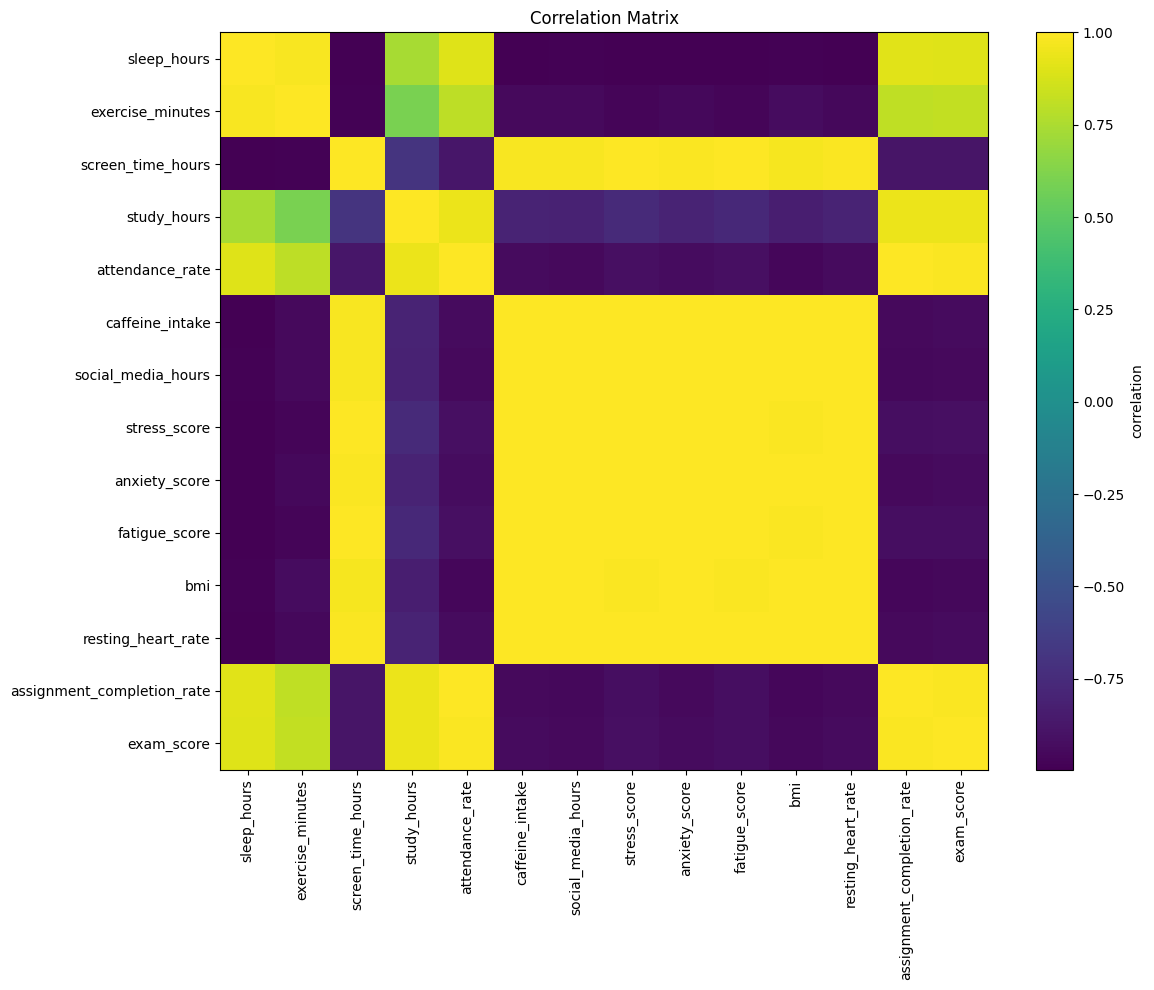

In [10]:
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. 標準化

今回のデータは、単位がバラバラです。

- 睡眠時間：時間
- 運動時間：分
- 出席率：%
- カフェイン摂取量：mg
- スコア：0〜100

このまま分析すると、単位やスケールが大きい変数の影響が強くなります。  
そのため、平均0・標準偏差1に標準化します。

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

X_scaled_df.head()

,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score
0,0.713316,0.789859,-0.898508,-0.148334,0.666941,-0.972313,-0.925806,-0.780226,-0.887544,-0.927429,-0.846559,-0.783826,0.733539,0.459233
1,-0.998642,-1.102343,1.042421,-1.213715,-0.969725,0.952193,1.040601,0.983763,1.156402,1.175280,0.982625,0.962094,-0.951097,-1.118284
2,0.332881,-0.021085,-0.425111,1.490714,0.939719,-0.447448,-0.660075,-0.463612,-0.612398,-0.480044,-0.654013,-0.416264,0.877936,0.985072
3,1.569295,1.600803,-1.419245,0.343380,0.394164,-1.234746,-1.244682,-1.368222,-1.201998,-1.195860,-1.199559,-1.151388,0.637274,0.692939
4,-1.474186,-1.372657,1.563158,-1.541524,-1.856252,1.564536,1.731501,1.616989,1.588775,1.533188,1.592352,1.697218,-1.817481,-1.527270


In [12]:
X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_hours,100.0,7.116530e-16,1.005038,-1.759512,-0.998642,0.237772,0.832202,1.569295
exercise_minutes,100.0,-1.332268e-17,1.005038,-1.480783,-0.994217,-0.021085,0.965564,1.654866
screen_time_hours,100.0,-9.992007e-17,1.005038,-1.466585,-0.945848,-0.164742,0.947741,1.752516
study_hours,100.0,3.147482e-16,1.005038,-1.869334,-0.967858,0.261428,0.855583,1.490714
attendance_rate,100.0,7.771561e-17,1.005038,-2.265419,-0.833336,0.530553,0.735136,1.007914
caffeine_intake,100.0,-5.329071e-17,1.005038,-1.234746,-0.884835,-0.359970,0.963128,1.870708
social_media_hours,100.0,7.660539e-17,1.005038,-1.244682,-0.872659,-0.394344,0.934309,1.997231
stress_score,100.0,1.110223e-18,1.005038,-1.368222,-0.881994,-0.237460,0.949840,1.843142
anxiety_score,100.0,7.327472e-17,1.005038,-1.241304,-0.887544,-0.337251,1.077789,1.785308
fatigue_score,100.0,1.310063e-16,1.005038,-1.285337,-0.927429,-0.256352,1.085803,1.801619


## 7. 因子分析の実行

今回はサンプルとして、3因子で因子分析を行います。

想定する因子は以下です。

- Factor1：メンタル負荷因子
- Factor2：学習習慣因子
- Factor3：健康・生活習慣因子

ただし、因子名は分析前に決め打ちするものではありません。  
因子負荷量を確認したあとで、人間が意味を解釈して名前を付けます。

In [13]:
n_factors = 3

fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(X_scaled)

factor_scores[:5]

array([[-0.85451172, -0.37183439, -0.27845174],
       [ 1.08934682,  0.26435854,  2.31407123],
       [-0.62391487,  1.10260669, -1.09605277],
       [-1.12441779, -1.59546267,  0.94821198],
       [ 1.65347465, -0.75437792, -0.95106102]])

## 8. 因子負荷量の確認

因子負荷量は、「各変数が各因子とどれくらい強く関係しているか」を表します。

絶対値が大きいほど、その変数はその因子と強く関係していると考えます。  
正負の向きにも意味がありますが、まずは絶対値の大きさに注目します。

In [14]:
loadings = pd.DataFrame(
    fa.components_.T,
    index=feature_cols,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

loadings

,Factor1,Factor2,Factor3
sleep_hours,-0.987001,-0.135854,0.036395
exercise_minutes,-0.941219,-0.324667,0.027098
screen_time_hours,0.979963,0.190571,-0.036470
study_hours,-0.822930,0.533524,-0.111364
attendance_rate,-0.951709,0.299885,0.034861
caffeine_intake,0.997259,0.032996,-0.019430
social_media_hours,0.998244,0.022425,-0.034728
stress_score,0.993295,0.107178,-0.030090
anxiety_score,0.998096,0.055571,0.022418
fatigue_score,0.993976,0.106334,0.014335


In [15]:
# 絶対値が大きい順に確認
for factor in loadings.columns:
    print(f"\n{factor}")
    display(loadings[[factor]].assign(abs_loading=loadings[factor].abs()).sort_values("abs_loading", ascending=False))


Factor1


,Factor1,abs_loading
social_media_hours,0.998244,0.998244
anxiety_score,0.998096,0.998096
resting_heart_rate,0.997647,0.997647
bmi,0.997532,0.997532
caffeine_intake,0.997259,0.997259
fatigue_score,0.993976,0.993976
stress_score,0.993295,0.993295
sleep_hours,-0.987001,0.987001
screen_time_hours,0.979963,0.979963
assignment_completion_rate,-0.959314,0.959314



Factor2


,Factor2,abs_loading
study_hours,0.533524,0.533524
exercise_minutes,-0.324667,0.324667
attendance_rate,0.299885,0.299885
assignment_completion_rate,0.281577,0.281577
exam_score,0.268928,0.268928
screen_time_hours,0.190571,0.190571
sleep_hours,-0.135854,0.135854
stress_score,0.107178,0.107178
fatigue_score,0.106334,0.106334
anxiety_score,0.055571,0.055571



Factor3


,Factor3,abs_loading
study_hours,-0.111364,0.111364
exam_score,-0.081093,0.081093
bmi,-0.052716,0.052716
screen_time_hours,-0.036470,0.036470
sleep_hours,0.036395,0.036395
attendance_rate,0.034861,0.034861
social_media_hours,-0.034728,0.034728
resting_heart_rate,-0.034675,0.034675
stress_score,-0.030090,0.030090
exercise_minutes,0.027098,0.027098


## 9. 因子負荷量の可視化

各因子に対して、どの変数の負荷量が大きいかを棒グラフで確認します。

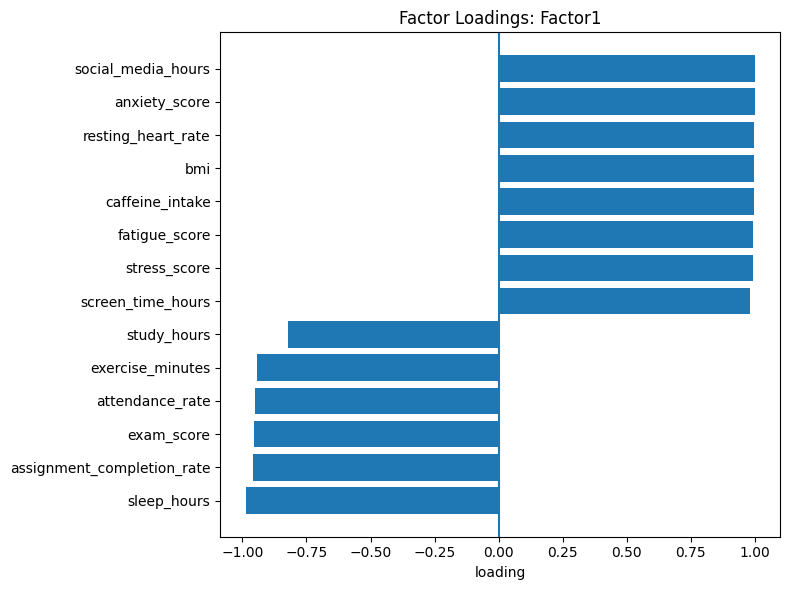

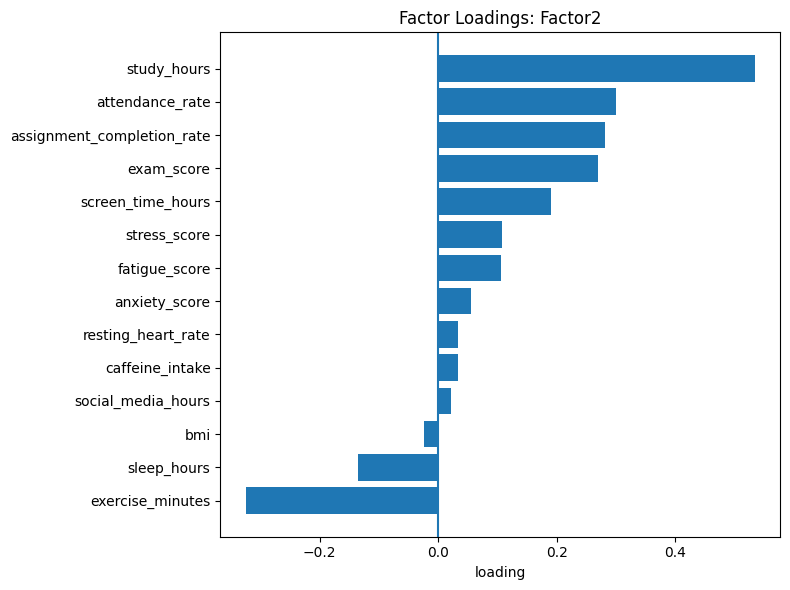

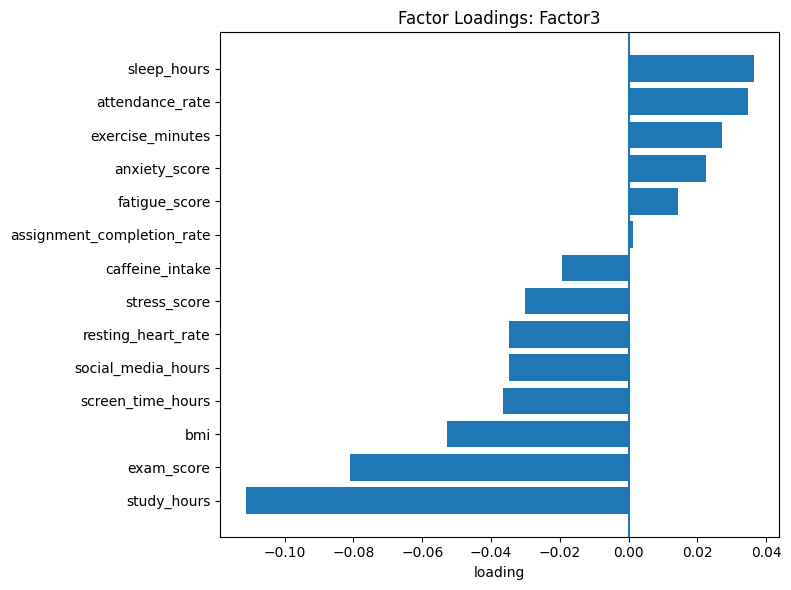

In [16]:
for factor in loadings.columns:
    sorted_loadings = loadings[factor].sort_values()

    plt.figure(figsize=(8, 6))
    plt.barh(sorted_loadings.index, sorted_loadings.values)
    plt.axvline(0)
    plt.title(f"Factor Loadings: {factor}")
    plt.xlabel("loading")
    plt.tight_layout()
    plt.show()

## 10. 因子の解釈

因子分析では、出てきた因子に対して人間が意味を解釈します。

例：

- `stress_score`、`anxiety_score`、`fatigue_score` が高く載る因子  
  → メンタル負荷因子

- `study_hours`、`attendance_rate`、`assignment_completion_rate`、`exam_score` が高く載る因子  
  → 学習習慣因子

- `sleep_hours`、`exercise_minutes`、`resting_heart_rate`、`bmi` が関連する因子  
  → 健康・生活習慣因子

実際には、因子の正負の向きは反転することがあります。  
そのため、「正だから良い」「負だから悪い」とすぐに判断せず、どの変数がまとまっているかを見ることが重要です。

## 11. 因子スコアの作成

因子スコアは、各学生がそれぞれの因子をどの程度持っているかを表す値です。

たとえば、メンタル負荷因子のスコアが高い学生は、ストレス・不安・疲労に関する傾向が強い可能性があります。

In [17]:
factor_score_df = pd.DataFrame(
    factor_scores,
    columns=[f"Factor{i+1}_score" for i in range(n_factors)]
)

result_df = pd.concat([df[["student_id"]], factor_score_df], axis=1)

result_df.head()

,student_id,Factor1_score,Factor2_score,Factor3_score
0,S001,-0.854512,-0.371834,-0.278452
1,S002,1.089347,0.264359,2.314071
2,S003,-0.623915,1.102607,-1.096053
3,S004,-1.124418,-1.595463,0.948212
4,S005,1.653475,-0.754378,-0.951061


In [18]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Factor1_score,100.0,3.441691e-17,1.004998,-1.186513,-0.842701,-0.412447,1.026448,1.916244
Factor2_score,100.0,1.221245e-17,1.003437,-1.595463,-0.853878,-0.344462,1.156872,1.889213
Factor3_score,100.0,4.585221e-16,0.953817,-2.078975,-0.658713,-0.252298,0.518437,2.314071


## 12. 因子スコアの可視化

Factor1 と Factor2 を使って、学生ごとの位置を散布図で確認します。

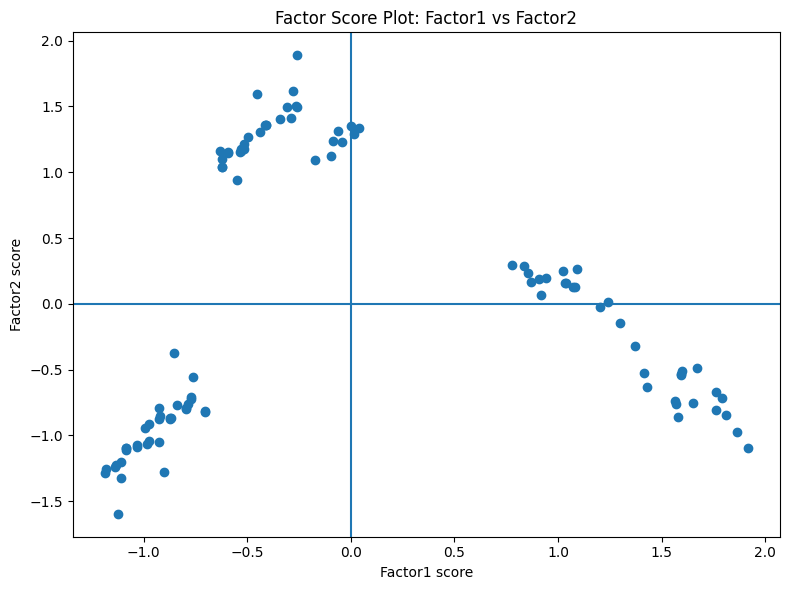

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(result_df["Factor1_score"], result_df["Factor2_score"])
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Factor1 score")
plt.ylabel("Factor2 score")
plt.title("Factor Score Plot: Factor1 vs Factor2")
plt.tight_layout()
plt.show()

## 13. 因子スコアと元データを結合して確認

元データと因子スコアを結合すると、個別の学生の特徴を確認しやすくなります。

In [20]:
df_with_factors = pd.concat([df, factor_score_df], axis=1)

df_with_factors.head()

,student_id,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score,Factor1_score,Factor2_score,Factor3_score
0,S001,7.2,45,3.1,2.5,92,120,1.8,35,28,30,21.5,62,95,82,-0.854512,-0.371834,-0.278452
1,S002,5.4,10,7.2,1.2,68,340,5.5,74,80,77,27.2,81,60,55,1.089347,0.264359,2.314071
2,S003,6.8,30,4.1,4.5,96,180,2.3,42,35,40,22.1,66,98,91,-0.623915,1.102607,-1.096053
3,S004,8.1,60,2.0,3.1,88,90,1.2,22,20,24,20.4,58,93,86,-1.124418,-1.595463,0.948212
4,S005,4.9,5,8.3,0.8,55,410,6.8,88,91,85,29.1,89,42,48,1.653475,-0.754378,-0.951061


In [21]:
# Factor1_score が高い学生を確認
df_with_factors.sort_values("Factor1_score", ascending=False).head(10)

,student_id,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score,Factor1_score,Factor2_score,Factor3_score
28,S029,4.6,3,8.7,0.4,49,440,7.3,93,96,91,30.5,92,35,42,1.916244,-1.098947,-2.078975
55,S056,4.6,4,8.6,0.5,50,445,7.2,92,95,90,30.4,91,37,43,1.863993,-0.972984,-2.022007
13,S014,4.7,4,8.5,0.5,51,430,7.1,91,94,89,30.2,91,39,45,1.808929,-0.847111,-1.873720
85,S086,4.7,5,8.5,0.6,53,435,7.0,91,94,89,30.0,90,40,44,1.789298,-0.713474,-1.262029
67,S068,4.7,5,8.3,0.6,54,430,6.9,90,94,88,30.1,90,41,45,1.763121,-0.668316,-1.011436
40,S041,4.7,5,8.4,0.6,53,435,7.0,90,93,88,30.0,90,40,44,1.762534,-0.806254,-1.573697
49,S050,4.8,6,8.2,0.8,56,425,6.7,89,92,86,29.7,89,44,46,1.669374,-0.485964,-0.919124
4,S005,4.9,5,8.3,0.8,55,410,6.8,88,91,85,29.1,89,42,48,1.653475,-0.754378,-0.951061
19,S020,4.8,6,8.1,0.9,58,420,6.6,87,90,84,29.5,88,45,47,1.596098,-0.510892,-1.067749
61,S062,4.9,7,8.1,0.7,58,420,6.6,87,90,84,29.4,88,45,47,1.593220,-0.534037,-0.817192


In [22]:
# Factor2_score が高い学生を確認
df_with_factors.sort_values("Factor2_score", ascending=False).head(10)

,student_id,sleep_hours,exercise_minutes,screen_time_hours,study_hours,attendance_rate,caffeine_intake,social_media_hours,stress_score,anxiety_score,fatigue_score,bmi,resting_heart_rate,assignment_completion_rate,exam_score,Factor1_score,Factor2_score,Factor3_score
5,S006,6.5,25,5.2,4.0,94,200,3.1,51,47,50,23.0,68,96,89,-0.259395,1.889213,0.589077
26,S027,6.5,26,5.0,3.9,93,205,3.0,50,46,48,23.2,69,95,88,-0.280185,1.615167,-0.027019
14,S015,6.6,28,4.8,4.1,96,190,2.7,46,41,44,22.9,67,98,92,-0.452321,1.593963,-0.758497
95,S096,6.5,26,5.1,3.8,92,210,3.1,50,46,48,23.3,69,94,87,-0.263090,1.501203,-0.356438
89,S090,6.6,28,4.9,3.9,93,205,3.1,49,45,47,23.2,68,95,88,-0.309895,1.499514,-0.213549
71,S072,6.5,25,5.0,3.8,92,210,3.2,50,46,48,23.4,69,94,87,-0.260503,1.494657,-0.496847
44,S045,6.5,27,5.1,3.8,92,210,3.1,49,45,47,23.3,69,94,87,-0.288557,1.415585,-0.734504
65,S066,6.6,28,4.8,3.9,93,205,3.0,48,44,46,23.1,68,95,88,-0.340542,1.406119,-0.318408
98,S099,6.7,31,4.6,4.0,94,190,2.8,47,42,45,22.7,67,96,89,-0.413232,1.363014,-0.004045
35,S036,6.7,31,4.6,4.0,94,195,2.8,47,42,45,22.8,67,96,89,-0.410808,1.362668,-0.130053


## 14. まとめ

このNotebookでは、学生生活・健康・学習習慣データに対して因子分析を行いました。

今回のポイントは以下です。

- 因子分析は、観測変数の背後にある共通因子を探す方法
- 単位が異なる量的データでは、標準化が重要
- 因子負荷量を見ることで、各因子の意味を解釈できる
- 因子スコアを見ることで、各サンプルの特徴を確認できる

主成分分析（PCA）が「データをうまく要約する」手法だとすると、  
因子分析は「変数の背後にある意味を探す」手法です。